#### Imports
#### Load Data
#### 1. Baseline - Dummy Classifier
#### 2. Logistic Regression
#### 3. Random Forest
#### 4. XGBoost
#### 5. LightGBM
#### 6. Model Comparison
#### 7. Hyperparameter Tuning (על המודל הטוב ביותר)
#### 8. Final Evaluation on Test

# imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score, 
                              classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from src.data_cleaning_and_manipulations import build_probability_table
from src.data_cleaning_and_manipulations import drop_unnecessary_columns,manipulate_df_process, apply_early_probability
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [2]:
train_df = pd.read_csv(r'../data/model_datasets/train_df.csv', encoding='utf-8-sig')
val_df = pd.read_csv(r'../data/model_datasets/val_df.csv', encoding='utf-8-sig')
test_df  = pd.read_csv(r'../data/model_datasets/test_df.csv', encoding='utf-8-sig')

### Run the Train DF through the manipulation functions
train_df = manipulate_df_process(train_df)
### Important - the prob_table (early trips) is calculated only on the Train
prob_table = build_probability_table(train_df, smoothing_alpha=0)
train_df = apply_early_probability(train_df, prob_table)
### Drop unnecessary columns
train_df = drop_unnecessary_columns(train_df)

### Run the Val DF through the manipulation functions
val_df = manipulate_df_process(val_df)
# Important - use the prob_table calculate on the Train
val_df = apply_early_probability(val_df, prob_table)
val_df = drop_unnecessary_columns(val_df)

### Run the Test DF through the manipulation functions
test_df = manipulate_df_process(test_df)
# Important - use the prob_table calculate on the Train
test_df = apply_early_probability(test_df, prob_table)
test_df = drop_unnecessary_columns(test_df)

In [3]:
# Define features and target
best_features = ['is_night', 'arrival_hour', 'departure_hour', 'Avg_Passengers_Per_Bus',
                 'agency_linenum_dir_alter_encoded', 'full_hour', 'agency_name_encoded',
                 'Total_Passengers', 'passengers_x_peak', 'day_encoded', 'time_of_day_encoded',
                 'perc_within_pt_route_peak', 'rainfall_mm',
                 'origin_station_encoded', 'route_length', 'night_x_long_route',
                 'destination_station_encoded', 'number_of_stops', 'origin_city_encoded',
                 'stops_x_passengers', 'destination_city_encoded', 'length_in_buffer_m',
                 'speed_kmh_planned', 'perc_within_pt_route', 'curvity', 'route_id','early_by_hour_length_proba','route_length_bin_encoded']

target_col = 'delay_cat'
cols_to_exclude = [target_col, 'duration_difference_min']

X_train = train_df.drop(columns=cols_to_exclude, errors='ignore')
y_train = train_df[target_col]

X_val = val_df.drop(columns=cols_to_exclude, errors='ignore')
y_val = val_df[target_col]

X_test = test_df.drop(columns=cols_to_exclude, errors='ignore')
y_test = test_df[target_col]

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (63365, 32)
X_val:   (13563, 32)
X_test:  (13588, 32)


# Functions

In [5]:
def evaluate_model(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)
    
    acc     = accuracy_score(y_val, y_pred)
    f1_mac  = f1_score(y_val, y_pred, average='macro')
    f1_del  = f1_score(y_val, y_pred, labels=['delay'], average='macro')
    f1_ear  = f1_score(y_val, y_pred, labels=['early'], average='macro')
    f1_ont  = f1_score(y_val, y_pred, labels=['on_time'], average='macro')
    rec_del = recall_score(y_val, y_pred, labels=['delay'], average='macro')
    rec_ear = recall_score(y_val, y_pred, labels=['early'], average='macro')
    rec_ont = recall_score(y_val, y_pred, labels=['on_time'], average='macro')

    print(f"=== {model_name} ===")
    print(f"Accuracy:         {acc:.3f}")
    print(f"F1 Macro:         {f1_mac:.3f}")
    print(f"F1 Delay:         {f1_del:.3f}")
    print(f"F1 Early:         {f1_ear:.3f}")
    print(f"F1 On Time:       {f1_ont:.3f}")
    print(f"Recall Delay:     {rec_del:.3f}")
    print(f"Recall Early:     {rec_ear:.3f}")
    print(f"Recall On Time:   {rec_ont:.3f}")
    print(f"\n{classification_report(y_val, y_pred)}")

    cm = confusion_matrix(y_val, y_pred, labels=['delay', 'early', 'on_time'])
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['delay', 'early', 'on_time'],
                yticklabels=['delay', 'early', 'on_time'])
    plt.title(f'Confusion Matrix - {model_name}', fontsize=13)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {
        'Model':          model_name,
        'Accuracy':       acc,
        'F1_Macro':       f1_mac,
        'F1_Delay':       f1_del,
        'F1_Early':       f1_ear,
        'F1_OnTime':      f1_ont,
        'Recall_Delay':   rec_del,
        'Recall_Early':   rec_ear,
        'Recall_OnTime':  rec_ont,
        'F1_Delay_Early': (f1_del + f1_ear) / 2
    }

results = []

def evaluate_model_pred(y_true, y_pred, model_name):
    acc     = accuracy_score(y_true, y_pred)
    f1_mac  = f1_score(y_true, y_pred, average='macro')
    f1_del  = f1_score(y_true, y_pred, labels=['delay'], average='macro')
    f1_ear  = f1_score(y_true, y_pred, labels=['early'], average='macro')
    f1_ont  = f1_score(y_true, y_pred, labels=['on_time'], average='macro')
    rec_del = recall_score(y_true, y_pred, labels=['delay'], average='macro')
    rec_ear = recall_score(y_true, y_pred, labels=['early'], average='macro')
    rec_ont = recall_score(y_true, y_pred, labels=['on_time'], average='macro')

    print(f"=== {model_name} ===")
    print(f"Accuracy:         {acc:.3f}")
    print(f"F1 Macro:         {f1_mac:.3f}")
    print(f"F1 Delay:         {f1_del:.3f}")
    print(f"F1 Early:         {f1_ear:.3f}")
    print(f"F1 On Time:       {f1_ont:.3f}")
    print(f"Recall Delay:     {rec_del:.3f}")
    print(f"Recall Early:     {rec_ear:.3f}")
    print(f"Recall On Time:   {rec_ont:.3f}")
    print(f"\n{classification_report(y_true, y_pred)}")

    cm = confusion_matrix(y_true, y_pred, labels=['delay', 'early', 'on_time'])
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['delay', 'early', 'on_time'],
                yticklabels=['delay', 'early', 'on_time'])
    plt.title(f'Confusion Matrix - {model_name}', fontsize=13)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {
        'Model':          model_name,
        'Accuracy':       acc,
        'F1_Macro':       f1_mac,
        'F1_Delay':       f1_del,
        'F1_Early':       f1_ear,
        'F1_OnTime':      f1_ont,
        'Recall_Delay':   rec_del,
        'Recall_Early':   rec_ear,
        'Recall_OnTime':  rec_ont,
        'F1_Delay_Early': (f1_del + f1_ear) / 2
    }

def check_overfitting(model, X_train, y_train, X_val, y_val, model_name, le=None):
    
    if le is not None:
        y_train_pred = le.inverse_transform(model.predict(X_train))
        y_val_pred = le.inverse_transform(model.predict(X_val))
    else:
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
    
    metrics = {
        'Model': model_name,
        'Train Accuracy':    accuracy_score(y_train, y_train_pred),
        'Val Accuracy':      accuracy_score(y_val, y_val_pred),
        'Train F1 Macro':    f1_score(y_train, y_train_pred, average='macro'),
        'Val F1 Macro':      f1_score(y_val, y_val_pred, average='macro'),
        'Train F1 Early':    f1_score(y_train, y_train_pred, labels=['early'], average='macro'),
        'Val F1 Early':      f1_score(y_val, y_val_pred, labels=['early'], average='macro'),
    }
    
    metrics['Gap Accuracy'] = metrics['Train Accuracy'] - metrics['Val Accuracy']
    metrics['Gap F1 Macro'] = metrics['Train F1 Macro'] - metrics['Val F1 Macro']
    
    return metrics    

# 1. Baseline Models

## Dummy Classifier

=== Dummy Most Frequent ===
Accuracy:         0.704
F1 Macro:         0.276
F1 Delay:         0.827
F1 Early:         0.000
F1 On Time:       0.000
Recall Delay:     1.000
Recall Early:     0.000
Recall On Time:   0.000

              precision    recall  f1-score   support

       delay       0.70      1.00      0.83      9553
       early       0.00      0.00      0.00       740
     on_time       0.00      0.00      0.00      3270

    accuracy                           0.70     13563
   macro avg       0.23      0.33      0.28     13563
weighted avg       0.50      0.70      0.58     13563



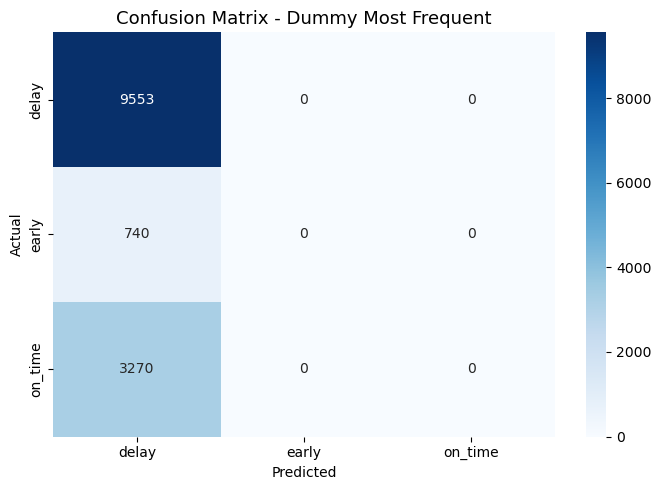

In [6]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
results.append(evaluate_model(dummy, X_val, y_val, 'Dummy Most Frequent'))

## Stratified 

=== Dummy Stratified ===
Accuracy:         0.559
F1 Macro:         0.327
F1 Delay:         0.706
F1 Early:         0.036
F1 On Time:       0.240
Recall Delay:     0.708
Recall Early:     0.035
Recall On Time:   0.239

              precision    recall  f1-score   support

       delay       0.70      0.71      0.71      9553
       early       0.04      0.04      0.04       740
     on_time       0.24      0.24      0.24      3270

    accuracy                           0.56     13563
   macro avg       0.33      0.33      0.33     13563
weighted avg       0.56      0.56      0.56     13563



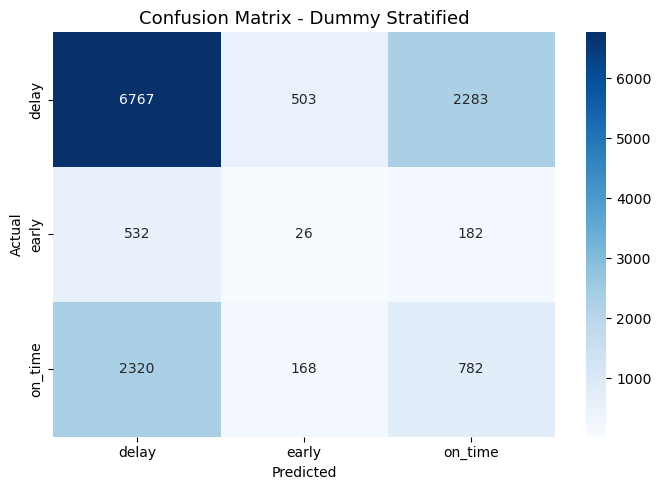

In [7]:
# Baseline 2 - Stratified (מנחש לפי התפלגות הקלאסים)
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train, y_train)
results.append(evaluate_model(dummy_strat, X_val, y_val, 'Dummy Stratified'))

# 2. Logistic Regression

=== Logistic Regression ===
Accuracy:         0.624
F1 Macro:         0.490
F1 Delay:         0.748
F1 Early:         0.204
F1 On Time:       0.518
Recall Delay:     0.640
Recall Early:     0.392
Recall On Time:   0.628

              precision    recall  f1-score   support

       delay       0.90      0.64      0.75      9553
       early       0.14      0.39      0.20       740
     on_time       0.44      0.63      0.52      3270

    accuracy                           0.62     13563
   macro avg       0.49      0.55      0.49     13563
weighted avg       0.75      0.62      0.66     13563



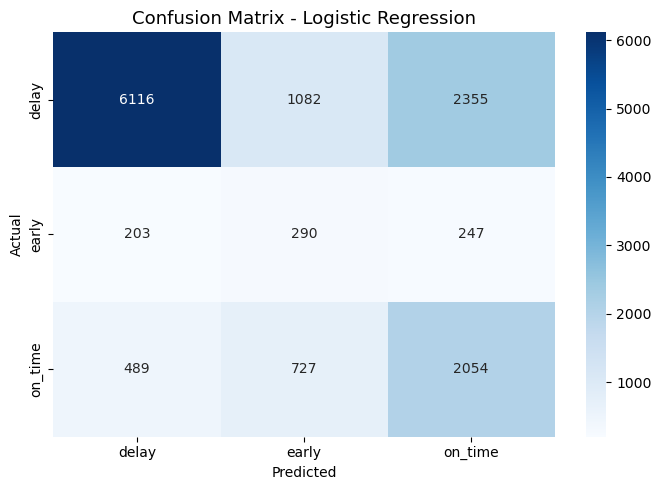

In [8]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
results.append(evaluate_model(lr, X_val, y_val, 'Logistic Regression'))

# 3. Random Forest

=== Random Forest ===
Accuracy:         0.806
F1 Macro:         0.647
F1 Delay:         0.884
F1 Early:         0.420
F1 On Time:       0.637
Recall Delay:     0.910
Recall Early:     0.336
Recall On Time:   0.610

              precision    recall  f1-score   support

       delay       0.86      0.91      0.88      9553
       early       0.56      0.34      0.42       740
     on_time       0.67      0.61      0.64      3270

    accuracy                           0.81     13563
   macro avg       0.69      0.62      0.65     13563
weighted avg       0.80      0.81      0.80     13563



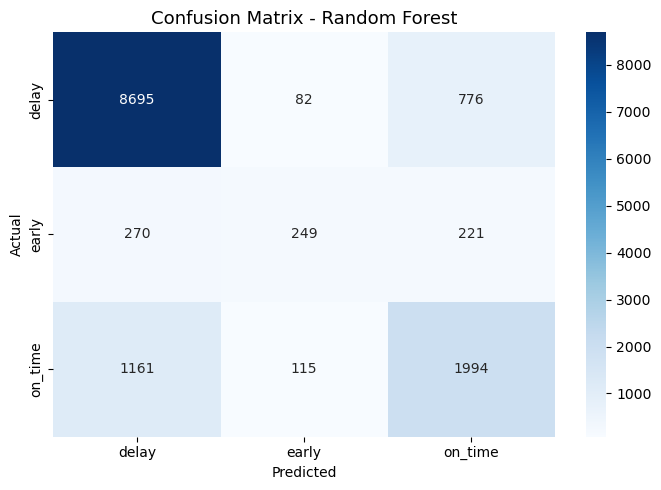

In [9]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model(rf, X_val, y_val, 'Random Forest'))

# 4. XGBoost

=== XGBoost ===
Accuracy:         0.823
F1 Macro:         0.663
F1 Delay:         0.895
F1 Early:         0.439
F1 On Time:       0.655
Recall Delay:     0.935
Recall Early:     0.316
Recall On Time:   0.611

              precision    recall  f1-score   support

       delay       0.86      0.93      0.89      9553
       early       0.72      0.32      0.44       740
     on_time       0.71      0.61      0.65      3270

    accuracy                           0.82     13563
   macro avg       0.76      0.62      0.66     13563
weighted avg       0.81      0.82      0.81     13563



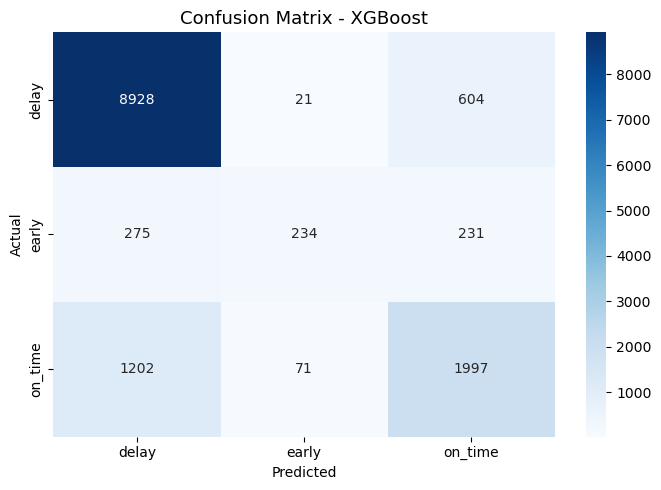

In [11]:
from sklearn.preprocessing import LabelEncoder
 
# המר כל עמודות category ל-int לפני הרצת XGBoost
for col in X_train.select_dtypes(include='category').columns:
    X_train[col] = X_train[col].astype(int)

for col in X_val.select_dtypes(include='category').columns:
    X_val[col] = X_val[col].astype(int)

for col in X_test.select_dtypes(include='category').columns:
    X_test[col] = X_test[col].astype(int)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                    subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train_enc)
y_pred_xgb = le.inverse_transform(xgb.predict(X_val))
results.append(evaluate_model_pred(y_val, y_pred_xgb, 'XGBoost'))

# 5. LightGBM

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009001 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4310
[LightGBM] [Info] Number of data points in the train set: 63365, number of used features: 32
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

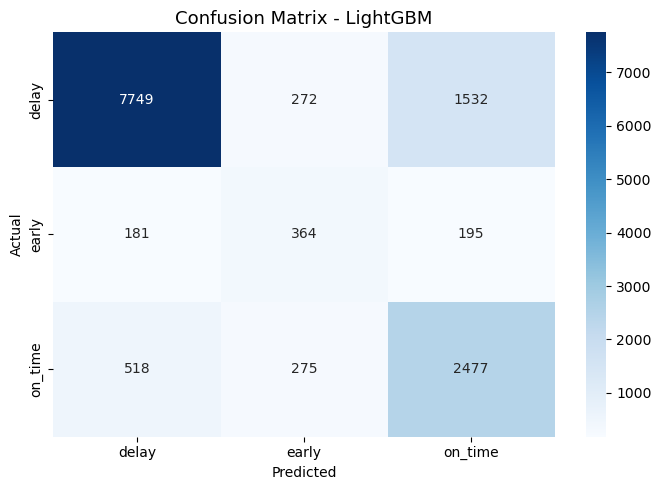

In [12]:
#!pip install lightgbm

from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                      random_state=42, class_weight='balanced', n_jobs=-1)
lgbm.fit(X_train, y_train)
results.append(evaluate_model(lgbm, X_val, y_val, 'LightGBM'))

# 6.  Model Comparison Summary

In [13]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1_Delay_Early', ascending=False)
print(results_df[['Model', 'Accuracy', 'F1_Macro', 'F1_Delay', 'F1_Early', 
                   'Recall_Delay', 'Recall_Early', 'F1_Delay_Early']])

                 Model  Accuracy  F1_Macro  F1_Delay  F1_Early  Recall_Delay  \
4              XGBoost  0.822753  0.662748  0.894679  0.439024      0.934576   
3        Random Forest  0.806459  0.646847  0.883683  0.419899      0.910185   
5             LightGBM  0.780801  0.654909  0.860952  0.440945      0.811159   
2  Logistic Regression  0.623756  0.490074  0.747632  0.204297      0.640218   
0  Dummy Most Frequent  0.704343  0.275509  0.826527  0.000000      1.000000   
1     Dummy Stratified  0.558505  0.327367  0.705925  0.036186      0.708364   

   Recall_Early  F1_Delay_Early  
4      0.316216        0.666852  
3      0.336486        0.651791  
5      0.491892        0.650949  
2      0.391892        0.475964  
0      0.000000        0.413264  
1      0.035135        0.371056  


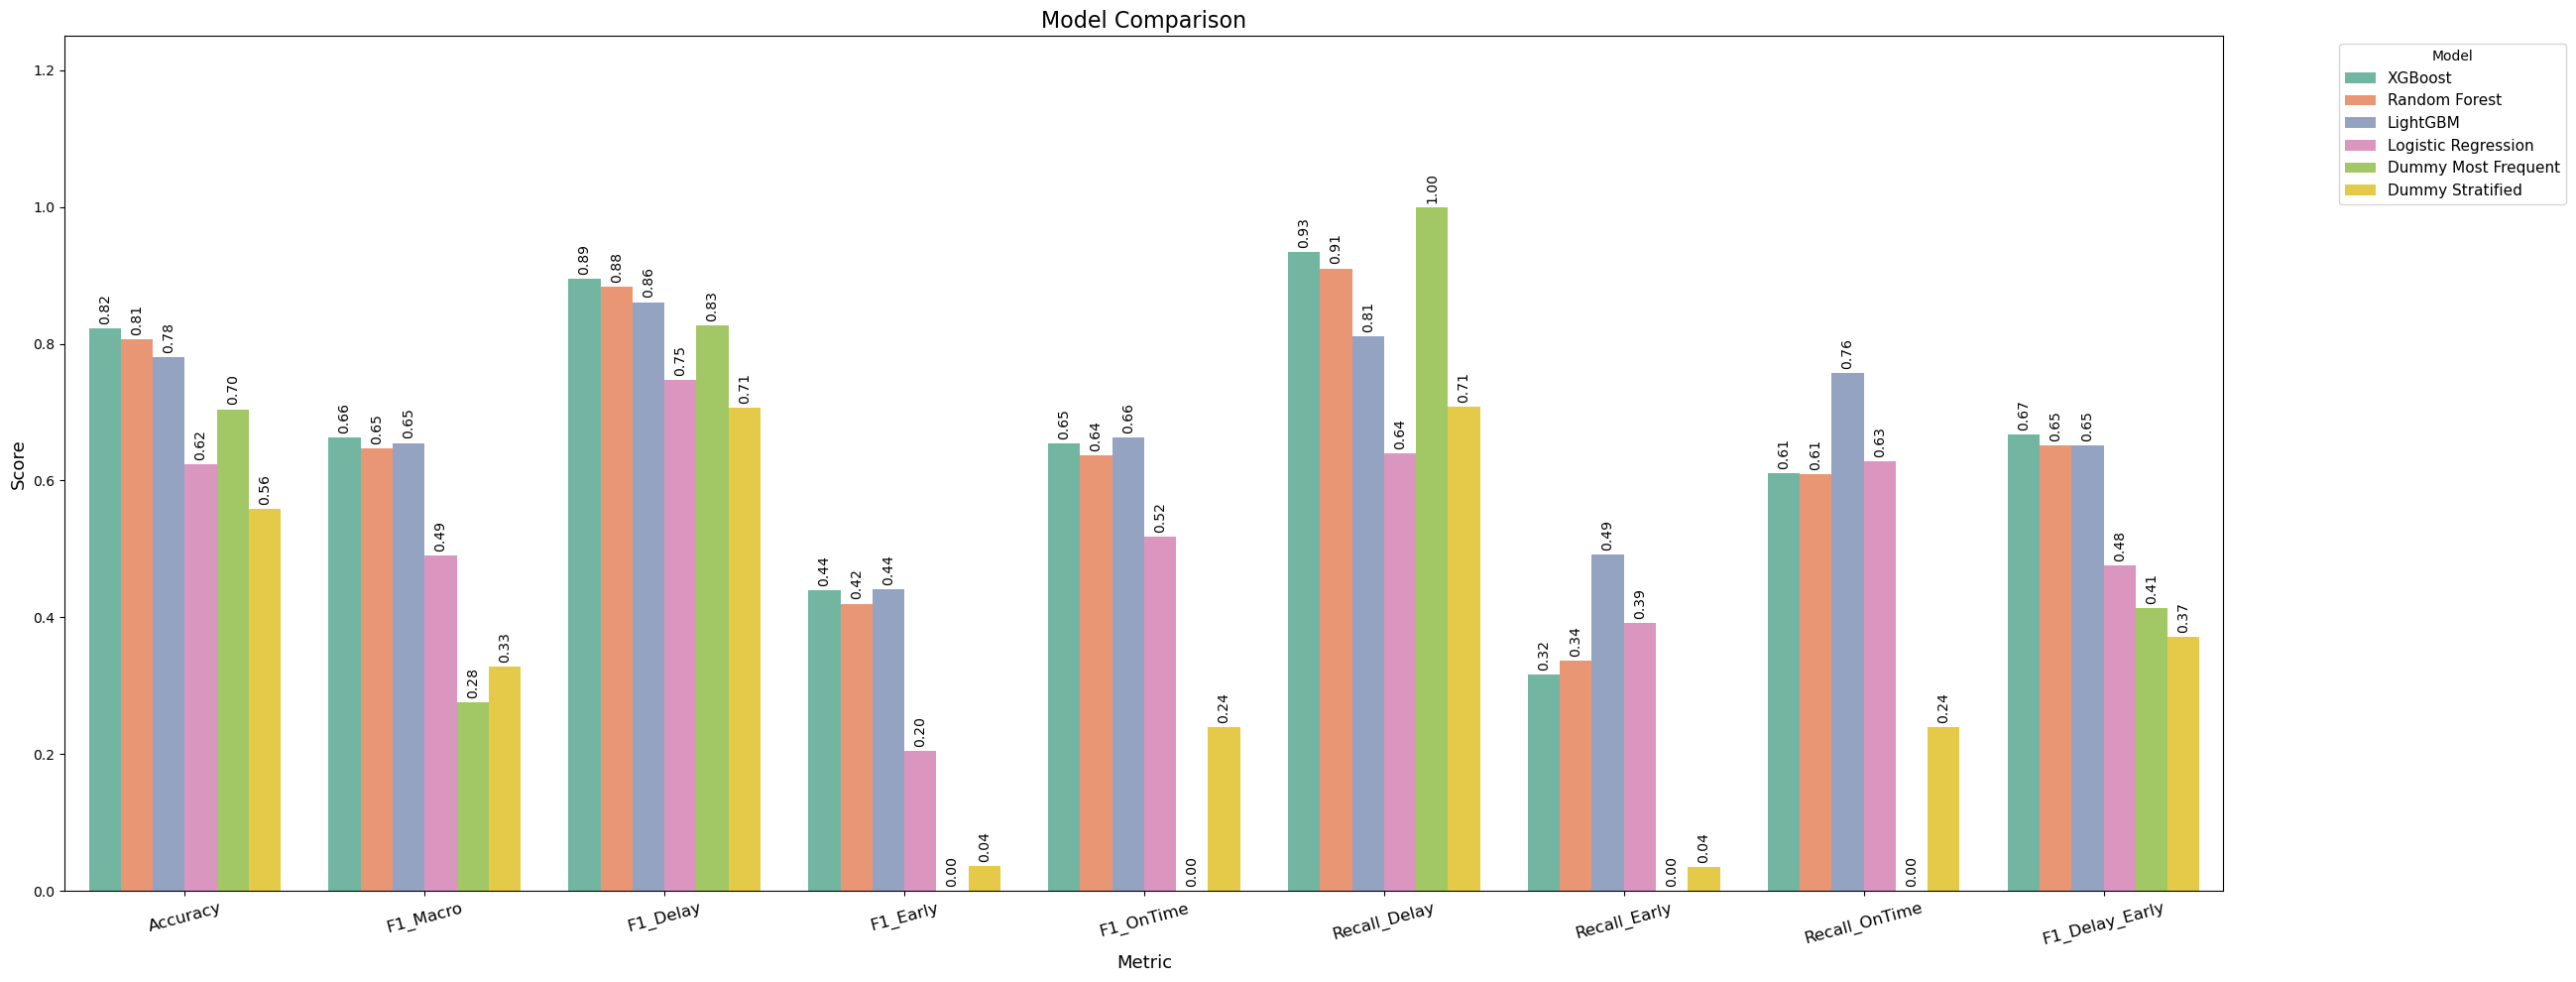

In [14]:
results_df = pd.DataFrame(results).sort_values(by='F1_Delay_Early', ascending=False)

metrics = ['Accuracy', 'F1_Macro', 'F1_Delay', 'F1_Early', 'F1_OnTime',
           'Recall_Delay', 'Recall_Early', 'Recall_OnTime', 'F1_Delay_Early']

plot_df = results_df[['Model'] + metrics].melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(26, 10))
ax = sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='Set2')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, rotation=90, padding=3)

plt.title('Model Comparison', fontsize=16)
plt.xlabel('Metric', fontsize=13)
plt.ylabel('Score', fontsize=13)
plt.ylim(0, 1.25)
plt.xticks(rotation=15, fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

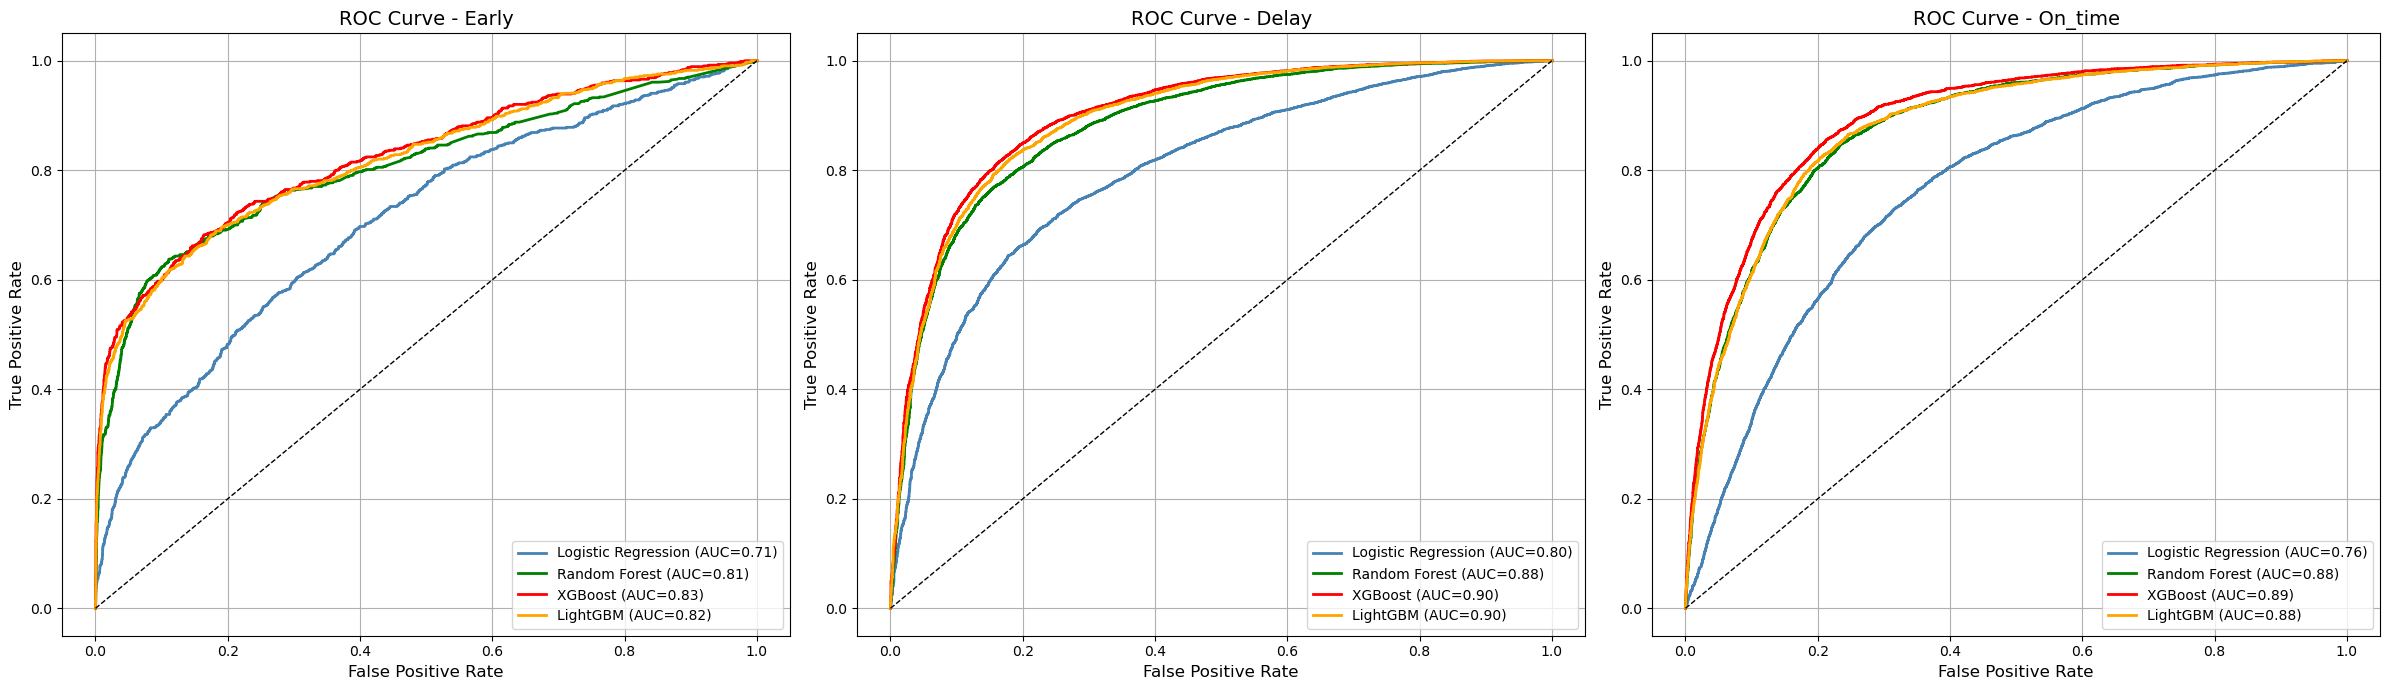

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = ['delay', 'early', 'on_time']
y_val_bin = label_binarize(y_val, classes=classes)

models_proba = {
    'Logistic Regression': lr.predict_proba(X_val),
    'Random Forest':       rf.predict_proba(X_val),
    'XGBoost':             xgb.predict_proba(X_val),
    'LightGBM':            lgbm.predict_proba(X_val)
}

colors = {'Logistic Regression': 'steelblue', 
          'Random Forest': 'green', 
          'XGBoost': 'red', 
          'LightGBM': 'orange'}

for ax, target_class in zip(axes, ['early', 'delay', 'on_time']):
    class_idx = classes.index(target_class)
    
    for model_name, proba in models_proba.items():
        fpr, tpr, _ = roc_curve(y_val_bin[:, class_idx], proba[:, class_idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[model_name], linewidth=2,
                label=f'{model_name} (AUC={roc_auc:.2f})')
    
    ax.plot([0,1], [0,1], 'k--', linewidth=1)
    ax.set_title(f'ROC Curve - {target_class.capitalize()}', fontsize=14)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Continue with XGBoost

## Check Overfitting

In [17]:


overfit_results = []
overfit_results.append(check_overfitting(xgb,  X_train, y_train, X_val, y_val, 'XGBoost', le=le))

overfit_df = pd.DataFrame(overfit_results)
print(overfit_df[['Model', 'Train Accuracy', 'Val Accuracy', 'Gap Accuracy', 
                   'Train F1 Macro', 'Val F1 Macro', 'Gap F1 Macro']].round(3))

     Model  Train Accuracy  Val Accuracy  Gap Accuracy  Train F1 Macro  \
0  XGBoost           0.858         0.823         0.035           0.737   

   Val F1 Macro  Gap F1 Macro  
0         0.663         0.075  


In [18]:
def check_overfitting_full(model, X_train, y_train, X_val, y_val, model_name, le=None):
    
    if le is not None:
        y_train_pred = le.inverse_transform(model.predict(X_train))
        y_val_pred = le.inverse_transform(model.predict(X_val))
    else:
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
    
    return {
        'Model': model_name,
        # Accuracy
        'Train Accuracy':    accuracy_score(y_train, y_train_pred),
        'Val Accuracy':      accuracy_score(y_val, y_val_pred),
        'Gap Accuracy':      accuracy_score(y_train, y_train_pred) - accuracy_score(y_val, y_val_pred),
        # F1 Macro
        'Train F1 Macro':    f1_score(y_train, y_train_pred, average='macro'),
        'Val F1 Macro':      f1_score(y_val, y_val_pred, average='macro'),
        'Gap F1 Macro':      f1_score(y_train, y_train_pred, average='macro') - f1_score(y_val, y_val_pred, average='macro'),
        # F1 Early
        'Train F1 Early':    f1_score(y_train, y_train_pred, labels=['early'], average='macro'),
        'Val F1 Early':      f1_score(y_val, y_val_pred, labels=['early'], average='macro'),
        'Gap F1 Early':      f1_score(y_train, y_train_pred, labels=['early'], average='macro') - f1_score(y_val, y_val_pred, labels=['early'], average='macro'),
        # F1 Delay
        'Train F1 Delay':    f1_score(y_train, y_train_pred, labels=['delay'], average='macro'),
        'Val F1 Delay':      f1_score(y_val, y_val_pred, labels=['delay'], average='macro'),
        'Gap F1 Delay':      f1_score(y_train, y_train_pred, labels=['delay'], average='macro') - f1_score(y_val, y_val_pred, labels=['delay'], average='macro'),
    }

result = check_overfitting_full(xgb, X_train, y_train, X_val, y_val, 'XGBoost', le=le)
pd.DataFrame([result]).T

,0
Model,XGBoost
Train Accuracy,0.857761
Val Accuracy,0.822753
Gap Accuracy,0.035008
Train F1 Macro,0.737415
Val F1 Macro,0.662748
Gap F1 Macro,0.074668
Train F1 Early,0.5625
Val F1 Early,0.439024
Gap F1 Early,0.123476


In [20]:
### There is no significant overfitting

## Use SMOTE – Synthetic Minority Over-sampling Technique

In [21]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Before SMOTE:
delay_cat
delay      44619
on_time    15355
early       3391
Name: count, dtype: int64

After SMOTE:
delay_cat
delay      44619
early      44619
on_time    44619
Name: count, dtype: int64


=== XGBoost + SMOTE ===
Accuracy:         0.671
F1 Macro:         0.539
F1 Delay:         0.806
F1 Early:         0.246
F1 On Time:       0.564
Recall Delay:     0.727
Recall Early:     0.661
Recall On Time:   0.511

              precision    recall  f1-score   support

       delay       0.90      0.73      0.81      9553
       early       0.15      0.66      0.25       740
     on_time       0.63      0.51      0.56      3270

    accuracy                           0.67     13563
   macro avg       0.56      0.63      0.54     13563
weighted avg       0.80      0.67      0.72     13563



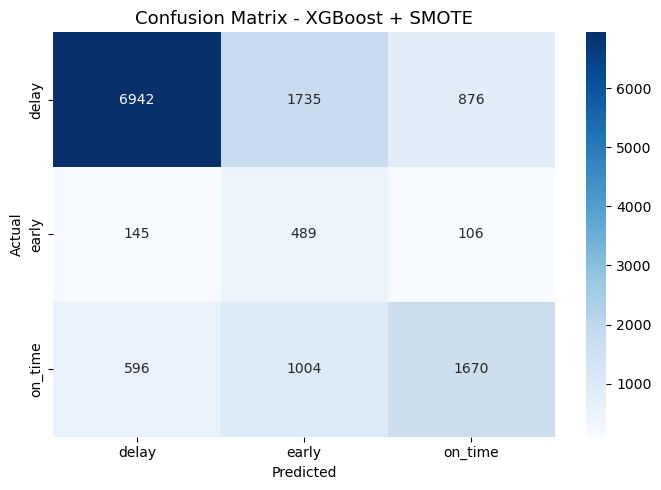

In [22]:
le_sm = LabelEncoder()
y_train_sm_enc = le_sm.fit_transform(y_train_sm)

xgb_sm = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_sm.fit(X_train_sm, y_train_sm_enc)

y_pred_sm = le_sm.inverse_transform(xgb_sm.predict(X_val))
results.append(evaluate_model_pred(y_val, y_pred_sm, 'XGBoost + SMOTE'))

In [23]:
## Bad Rseults

## Threshold Tuning

In [24]:
# קבל הסתברויות
y_proba = xgb.predict_proba(X_val)
early_idx = list(le.classes_).index('early')

# נסה סף נמוך יותר ל-early
threshold = 0.2  # במקום 0.33 (ברירת מחדל)

y_pred_thresh = []
for proba in y_proba:
    if proba[early_idx] >= threshold:
        y_pred_thresh.append('early')
    else:
        y_pred_thresh.append(le.classes_[np.argmax(proba)])

print(classification_report(y_val, y_pred_thresh))

              precision    recall  f1-score   support

       delay       0.86      0.93      0.89      9553
       early       0.59      0.45      0.51       740
     on_time       0.72      0.58      0.64      3270

    accuracy                           0.82     13563
   macro avg       0.72      0.65      0.68     13563
weighted avg       0.81      0.82      0.81     13563



In [25]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = []
    for proba in y_proba:
        if proba[early_idx] >= thresh:
            y_pred_thresh.append('early')
        else:
            y_pred_thresh.append(le.classes_[np.argmax(proba)])
    
    f1_ear = f1_score(y_val, y_pred_thresh, labels=['early'], average='macro')
    f1_del = f1_score(y_val, y_pred_thresh, labels=['delay'], average='macro')
    acc    = accuracy_score(y_val, y_pred_thresh)
    
    threshold_results.append({
        'Threshold': thresh,
        'Accuracy':  acc,
        'F1_Early':  f1_ear,
        'F1_Delay':  f1_del,
        'F1_Delay_Early': (f1_ear + f1_del) / 2
    })

pd.DataFrame(threshold_results)

,Threshold,Accuracy,F1_Early,F1_Delay,F1_Delay_Early
0,0.10,0.802772,0.452063,0.892747,0.672405
1,0.15,0.815528,0.493453,0.894501,0.693977
2,0.20,0.821352,0.511162,0.894716,0.702939
3,0.25,0.823859,0.508614,0.894935,0.701774
4,0.30,0.823490,0.484901,0.894798,0.689849


In [26]:
### The best Threshold is 0.20

## Hyperparameter Tuning - using Optuna 

In [27]:
!pip install optuna

import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'eval_metric': 'mlogloss',
        'random_state': 42
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train_enc)
    y_pred = le.inverse_transform(model.predict(X_val))
    
    # אופטימיזציה לפי F1 Delay+Early
    f1_del = f1_score(y_val, y_pred, labels=['delay'], average='macro')
    f1_ear = f1_score(y_val, y_pred, labels=['early'], average='macro')
    return (f1_del + f1_ear) / 2

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best F1 Delay+Early: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------- ----------------------------- 1/4 [colorlog]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------

[I 2026-05-06 16:03:34,064] A new study created in memory with name: no-name-28cddb91-448b-4ba0-b80d-d5b17a1605ba
[I 2026-05-06 16:03:37,724] Trial 0 finished with value: 0.6431426617959418 and parameters: {'n_estimators': 212, 'max_depth': 4, 'learning_rate': 0.22190537041045488, 'subsample': 0.5350083125032626, 'colsample_bytree': 0.8758060079205037, 'min_child_weight': 9, 'gamma': 4.800326371935519}. Best is trial 0 with value: 0.6431426617959418.
[I 2026-05-06 16:03:42,263] Trial 1 finished with value: 0.671659580057578 and parameters: {'n_estimators': 315, 'max_depth': 8, 'learning_rate': 0.24926842003613678, 'subsample': 0.9840090427847905, 'colsample_bytree': 0.6244165490370979, 'min_child_weight': 4, 'gamma': 0.45069633454697}. Best is trial 1 with value: 0.671659580057578.
[I 2026-05-06 16:03:44,923] Trial 2 finished with value: 0.6255798683181375 and parameters: {'n_estimators': 158, 'max_depth': 4, 'learning_rate': 0.12261787747649913, 'subsample': 0.6046214448684628, 'colsa

Best F1 Delay+Early: 0.6724
Best params: {'n_estimators': 272, 'max_depth': 7, 'learning_rate': 0.29675520017182233, 'subsample': 0.9115547349482451, 'colsample_bytree': 0.563141736396293, 'min_child_weight': 4, 'gamma': 0.7078916896955084}


The best results were of XGBoost + Threshold 0.20 : F1 Delay+Early = 0.703
XGBoost = 0.667
XGBoost + Optuna = 0.672

## Check results and overfit for XGBoost + Threshold 0.20

In [28]:
# Train predictions with threshold
y_proba_train = xgb.predict_proba(X_train)

y_pred_train_thresh = []
for proba in y_proba_train:
    if proba[early_idx] >= 0.20:
        y_pred_train_thresh.append('early')
    else:
        y_pred_train_thresh.append(le.classes_[np.argmax(proba)])

# Val predictions with threshold
y_pred_val_thresh = []
for proba in y_proba:
    if proba[early_idx] >= 0.20:
        y_pred_val_thresh.append('early')
    else:
        y_pred_val_thresh.append(le.classes_[np.argmax(proba)])

# השוואה
metrics = {
    'Train Accuracy':    accuracy_score(y_train, y_pred_train_thresh),
    'Val Accuracy':      accuracy_score(y_val, y_pred_val_thresh),
    'Train F1 Early':    f1_score(y_train, y_pred_train_thresh, labels=['early'], average='macro'),
    'Val F1 Early':      f1_score(y_val, y_pred_val_thresh, labels=['early'], average='macro'),
    'Train F1 Delay':    f1_score(y_train, y_pred_train_thresh, labels=['delay'], average='macro'),
    'Val F1 Delay':      f1_score(y_val, y_pred_val_thresh, labels=['delay'], average='macro'),
    'Train F1 D+E':      (f1_score(y_train, y_pred_train_thresh, labels=['delay'], average='macro') + 
                          f1_score(y_train, y_pred_train_thresh, labels=['early'], average='macro')) / 2,
    'Val F1 D+E':        (f1_score(y_val, y_pred_val_thresh, labels=['delay'], average='macro') + 
                          f1_score(y_val, y_pred_val_thresh, labels=['early'], average='macro')) / 2,
}

metrics['Gap Accuracy'] = metrics['Train Accuracy'] - metrics['Val Accuracy']
metrics['Gap F1 Early'] = metrics['Train F1 Early'] - metrics['Val F1 Early']
metrics['Gap F1 Delay'] = metrics['Train F1 Delay'] - metrics['Val F1 Delay']
metrics['Gap F1 D+E']   = metrics['Train F1 D+E'] - metrics['Val F1 D+E']

pd.DataFrame([metrics]).T.round(3)

,0
Train Accuracy,0.854
Val Accuracy,0.821
Train F1 Early,0.598
Val F1 Early,0.511
Train F1 Delay,0.914
Val F1 Delay,0.895
Train F1 D+E,0.756
Val F1 D+E,0.703
Gap Accuracy,0.033
Gap F1 Early,0.086


# Check final results on the test

In [30]:
y_proba_test = xgb.predict_proba(X_test)

y_pred_test = []
for proba in y_proba_test:
    if proba[early_idx] >= 0.20:
        y_pred_test.append('early')
    else:
        y_pred_test.append(le.classes_[np.argmax(proba)])

print("=== Final Evaluation on Test ===")
print(classification_report(y_test, y_pred_test))

=== Final Evaluation on Test ===
              precision    recall  f1-score   support

       delay       0.86      0.94      0.90      9607
       early       0.55      0.47      0.51       707
     on_time       0.73      0.57      0.64      3274

    accuracy                           0.82     13588
   macro avg       0.72      0.66      0.68     13588
weighted avg       0.81      0.82      0.81     13588



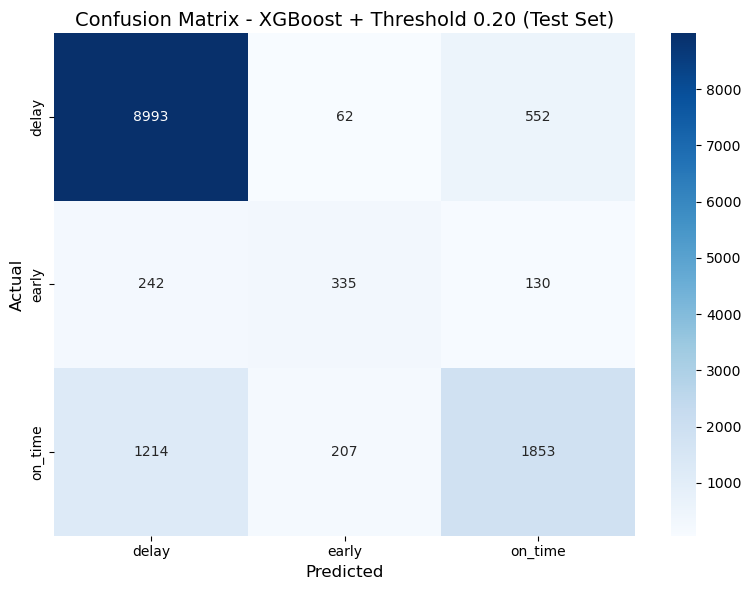

In [31]:
cm = confusion_matrix(y_test, y_pred_test, labels=['delay', 'early', 'on_time'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['delay', 'early', 'on_time'],
            yticklabels=['delay', 'early', 'on_time'])
plt.title('Confusion Matrix - XGBoost + Threshold 0.20 (Test Set)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------------------------- -- 524.3/555.9 kB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 555.9/555.9 kB 3.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]

<Figure size 640x480 with 0 Axes>

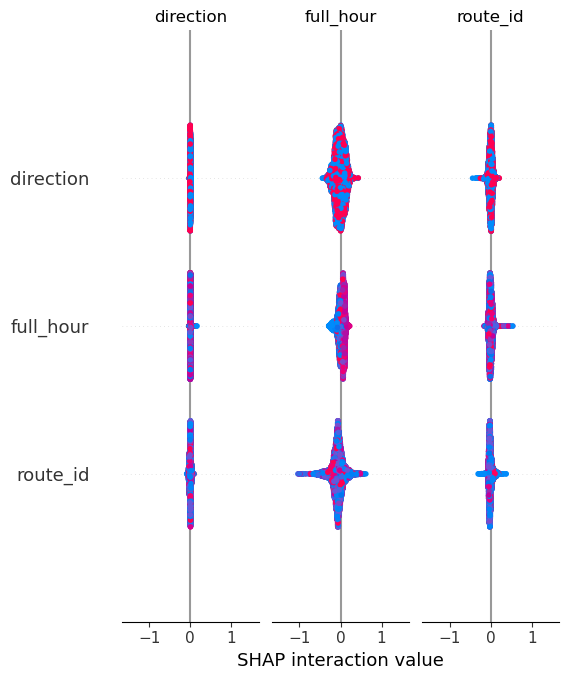

In [32]:
!pip install shap

import shap

# יצירת explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_val)

# Summary Plot - כל הקלאסים
plt.figure()
shap.summary_plot(shap_values, X_val, class_names=le.classes_, show=True)


In [33]:
# Summary Plot לכל קלאס בנפרד
class_names = list(le.classes_)

for i, class_name in enumerate(class_names):
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values[i], 
        X_val, 
        feature_names=X_val.columns,
        title=f'SHAP - {class_name}',
        show=True
    )

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1000x800 with 0 Axes>

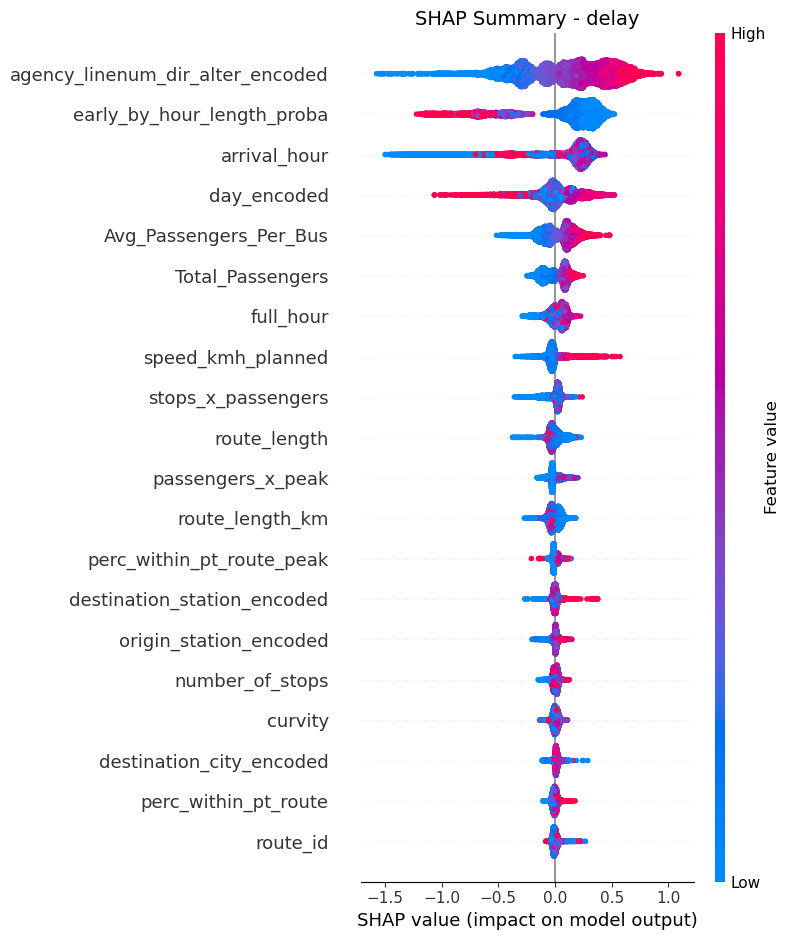

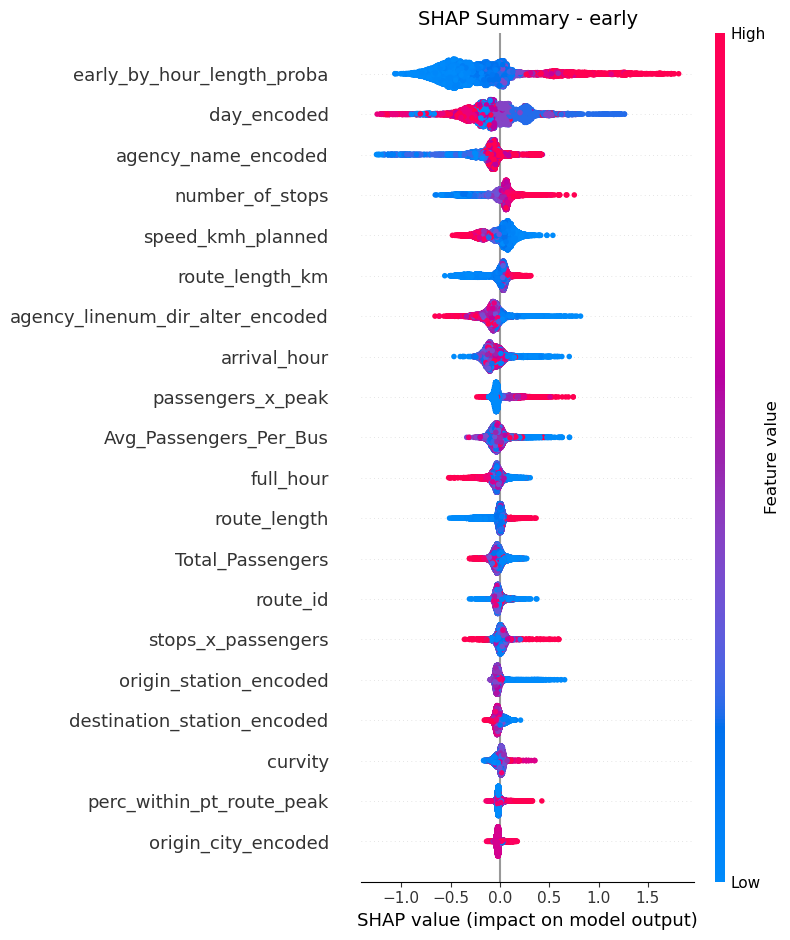

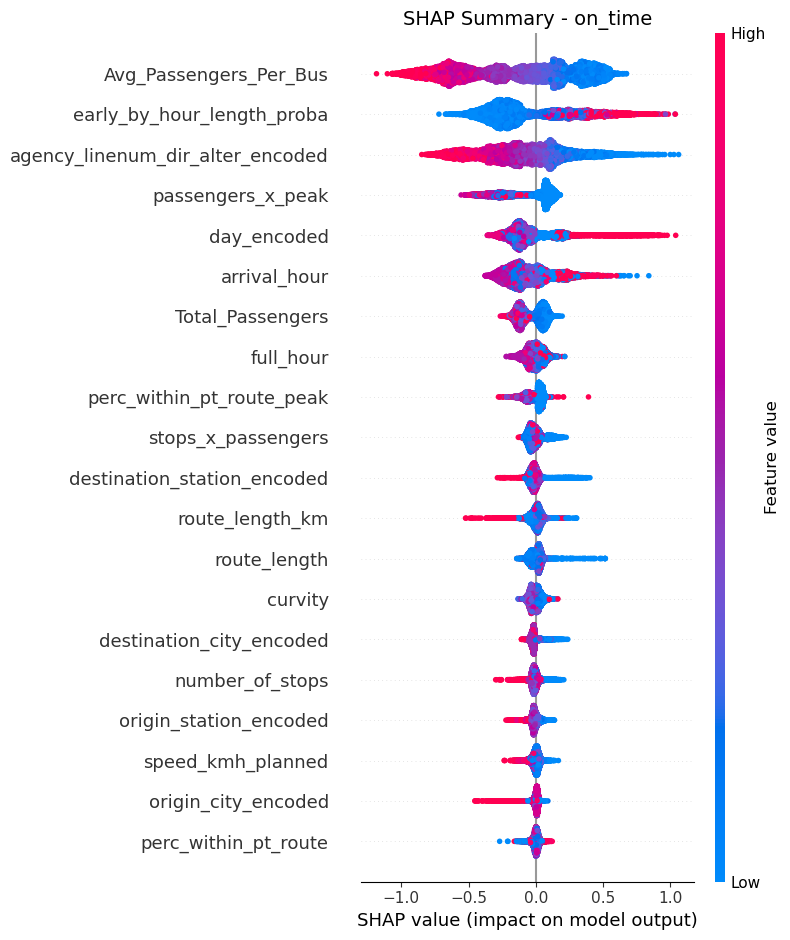

In [35]:
for i, class_name in enumerate(le.classes_):
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values[:, :, i],
        X_val,
        feature_names=X_val.columns.tolist(),
        show=False
    )
    plt.title(f'SHAP Summary - {class_name}', fontsize=14)
    plt.tight_layout()
    plt.show()